# Blood Glucose Statistical Analysis

Statistical analysis of fasting and post-glucose blood glucose levels across two control groups.

**Dataset**: 65 patients — 35 in Group 1, 30 in Group 2  
**Variables**: fasting glucose (basal) and glucose 60 minutes after intake  

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import median_abs_deviation, shapiro
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms

In [9]:
# Load dataset and split by control group
df = pd.read_excel("EVALMASTER.xlsx", usecols=["Grupo de control", "Nivel glucosa basal", "Nivel glucosa 60 min"])
df = df.dropna(subset=["Grupo de control"])

g1 = df[df["Grupo de control"] == 1][["Nivel glucosa basal", "Nivel glucosa 60 min"]].reset_index(drop=True)
g2 = df[df["Grupo de control"] == 2][["Nivel glucosa basal", "Nivel glucosa 60 min"]].reset_index(drop=True)

df

,Grupo de control,Nivel glucosa basal,Nivel glucosa 60 min
0,1.0,90.0,159.0
1,1.0,82.0,151.0
2,1.0,80.0,148.0
3,1.0,75.0,138.0
4,1.0,74.0,141.0
...,...,...,...
60,2.0,95.0,169.0
61,2.0,99.0,172.0
62,2.0,88.0,173.0
63,2.0,84.0,188.0


In [10]:
# Modify DataFrame for better visualization
df1 = pd.concat([g1, g2], axis=1)
df1.columns = ["Group1_Basal", "Group1_60min", "Group2_Basal", "Group2_60min"]

df1

,Group1_Basal,Group1_60min,Group2_Basal,Group2_60min
0,90.0,159.0,94.0,180.0
1,82.0,151.0,96.0,166.0
2,80.0,148.0,93.0,190.0
3,75.0,138.0,88.0,174.0
4,74.0,141.0,79.0,156.0
5,97.0,157.0,79.0,184.0
6,103.0,172.0,90.0,159.0
7,76.0,150.0,102.0,161.0
8,65.0,131.0,104.0,182.0
9,89.0,156.0,86.0,170.0


## 1. Descriptive Statistics

### Centrality and dispersion measures

In [11]:
def descriptive_stats(series, label):
    return pd.Series({
        "Count": series.count(),
        "Mean":series.mean(), 
        "Median":series.median(),
        "Mode":series.mode()[0],
        "Min": series.min(),
        "Max": series.max(),
        "Range":series.max() - series.min(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR":series.quantile(0.75) - series.quantile(0.25),
        "Variance":series.var(),
        "Std Dev":series.std(),
        "CV":series.std() / series.mean(),
    }, name=label)

summary = pd.concat([
    descriptive_stats(df1.Group1_Basal, 'Group1_Basal'),
    descriptive_stats(df1.Group1_60min, 'Group1_60min'),
    descriptive_stats(df1.Group2_Basal, 'Group2_Basal'),
    descriptive_stats(df1.Group2_60min, 'Group2_60min'),
], axis=1)
summary

,Group1_Basal,Group1_60min,Group2_Basal,Group2_60min
Count,35.000000,35.000000,30.000000,30.000000
Mean,84.685714,150.400000,89.400000,171.833333
Median,82.000000,150.000000,90.000000,172.000000
Mode,75.000000,150.000000,88.000000,172.000000
Min,65.000000,131.000000,77.000000,152.000000
Max,103.000000,172.000000,104.000000,197.000000
Range,38.000000,41.000000,27.000000,45.000000
Q1,78.500000,146.500000,84.500000,161.750000
Q3,90.500000,154.500000,94.000000,179.750000
IQR,12.000000,8.000000,9.500000,18.000000


Both groups show comparable baseline glucose levels, although Group 2 presents slightly higher central tendency values (mean, median and mode) compared to Group 1.

After 60 minutes, glucose levels increase markedly in both groups, indicating a clear post-intervention physiological response. This increase is more pronounced in Group 2, which consistently shows higher mean and median values than Group 1.

Measures of central tendency (mean, median, and mode) are very similar within each group and condition, suggesting approximately symmetric distributions without strong skewness.

Variability differs between conditions: dispersion is generally higher at 60 minutes, especially in Group 2, as reflected by its larger standard deviation, variance, and interquartile range (IQR).

Despite these differences in scale and variability, the coefficients of variation (CV < 0.11 in all cases) indicate low relative dispersion, confirming that the data within each group remain homogeneous.

Overall, Group 2 tends to exhibit higher glucose levels and greater variability after 60 minutes, suggesting a stronger and more heterogeneous response compared to Group 1.

### Skewness and kurtosis

In [12]:
def skew_kurtosis(series, label):
    return pd.Series({
        "Skew": series.skew(),
        "Kurtosis":series.kurt()
    }, name=label)

summary2 = pd.concat([
    skew_kurtosis(df1.Group1_Basal, "Group 1 — Basal"),
    skew_kurtosis(df1.Group1_60min, "Group 1 — 60 min"),
    skew_kurtosis(df1.Group2_Basal, "Group 2 — Basal"),
    skew_kurtosis(df1.Group2_60min, "Group 2 — 60 min"),
], axis=1)
summary2

,Group 1 — Basal,Group 1 — 60 min,Group 2 — Basal,Group 2 — 60 min
Skew,0.206769,0.363681,-0.007469,0.245866
Kurtosis,-0.496847,1.451600,-0.612661,-0.428693


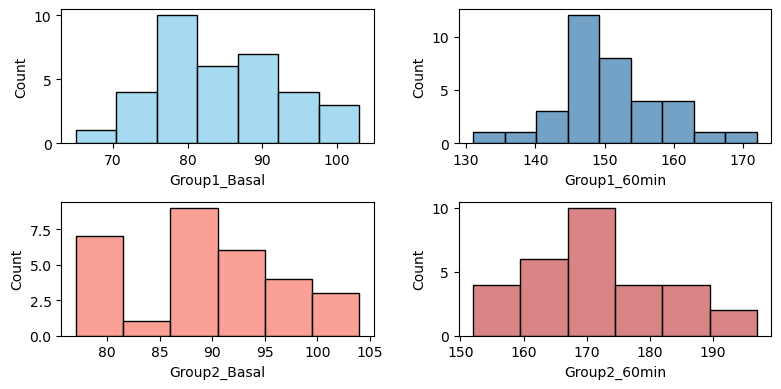

In [13]:
# Histogram
plt.figure(figsize=(8,4))
plt.subplot(2,2,1)
sns.histplot(data=df1.Group1_Basal, color='skyblue')
plt.subplot(2,2,2)
sns.histplot(data=df1.Group1_60min, color='steelblue')
plt.subplot(2,2,3)
sns.histplot(data=df1.Group2_Basal, color='salmon')
plt.subplot(2,2,4)
sns.histplot(data=df1.Group2_60min, color='indianred')
plt.tight_layout()
plt.show()

The skewness values are close to zero for all four datasets (ranging from -0.007 to 0.364), indicating that the glucose measurements are approximately symmetric. A slight positive skew is observed in both groups after 60 minutes, suggesting a small tendency toward higher glucose values, although the asymmetry is minimal.

Kurtosis values are generally close to zero, implying distributions similar to a normal distribution. The only exception is Group 1 at 60 minutes (kurtosis = 1.45), which exhibits a more peaked distribution with slightly heavier tails, although the deviation is not substantial.

The histograms support these findings, showing unimodal distributions without evidence of pronounced skewness, multimodality, or extreme outliers. Most observations are concentrated around the central values, with frequencies decreasing gradually toward the tails.

Overall, both the numerical indicators (skewness and kurtosis) and the graphical analysis suggest that the glucose data are reasonably close to a normal distribution. Therefore, the assumption of normality appears to be appropriate, supporting the use of parametric statistical methods in subsequent analyses.

## 2. Boxplots and outliers detection

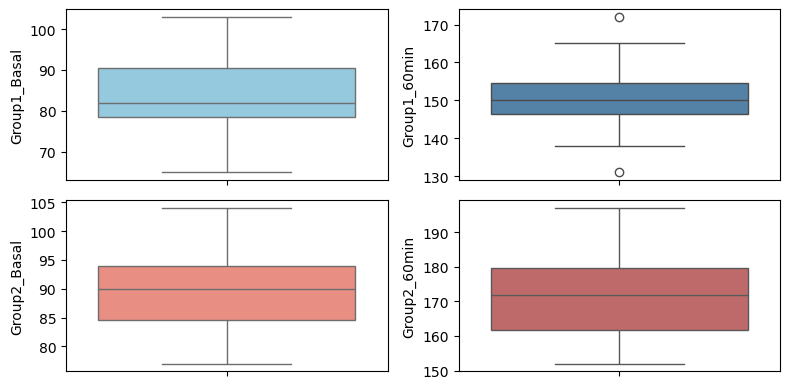

In [14]:
# Boxplots
plt.figure(figsize=(8,4))
plt.subplot(2,2,1)
sns.boxplot(data=df1.Group1_Basal, color='skyblue')
plt.subplot(2,2,2)
sns.boxplot(data=df1.Group1_60min, color='steelblue')
plt.subplot(2,2,3)
sns.boxplot(data=df1.Group2_Basal, color='salmon')
plt.subplot(2,2,4)
sns.boxplot(data=df1.Group2_60min, color='indianred')
plt.tight_layout()
plt.show()

In [15]:
# Detect outliers using the modified Z-score (MAD-based method)
# Two thresholds are used to capture both outliers identified in the Group1_60min boxplot
def detect_outliers_mad(series, label, threshold_extreme=3.5, threshold_mild=3.0):
    series = series.dropna()
    median = series.median()
    mad = median_abs_deviation(series)
    print(f"{label}")
    for x in series:
        z = 0.6745 * (x - median) / mad
        if abs(z) > threshold_extreme:
            print(f"Extreme outlier: {x} (modified Z = {z:.2f})")
        elif abs(z) > threshold_mild:
            print(f"Mild outlier: {x} (modified Z = {z:.2f})")

for col in df1.columns:
    detect_outliers_mad(df1[col], col)

Group1_Basal
Group1_60min
Extreme outlier: 172.0 (modified Z = 3.71)
Mild outlier: 131.0 (modified Z = -3.20)
Group2_Basal
Group2_60min


No outliers in fasting glucose. In the 60-min variable for group 1, 172 mg/dL is an extreme outlier and 131 mg/dL is a mild outlier — both visible in the boxplot above.

## 3. Normality Test (Shapiro-Wilk)

In [23]:
# H0: data follows a normal distribution
# H1: data does not follow a normal distribution

for col in df1.columns:
    stat, p = shapiro(df1[col].dropna())
    conclusion = "Normality not rejected" if p > 0.05 else "Normality rejected"
    print(f"{col}: W={stat:.4f}, p={p:.4f} - {conclusion}")

Group1_Basal: W=0.9679, p=0.3874 - Normality not rejected
Group1_60min: W=0.9626, p=0.2734 - Normality not rejected
Group2_Basal: W=0.9675, p=0.4741 - Normality not rejected
Group2_60min: W=0.9776, p=0.7592 - Normality not rejected


p > 0.05 for both groups so normality is not rejected. The Shapiro-Wilk test is appropriate here given the small sample sizes (n = 35 and n = 30).

## 4. Linear Regression (Group 1)
Linear relationship between fasting glucose and 60-min glucose

Covariance: 54.5118
Pearson correlation: 0.7964
p-value: 1.06e-08


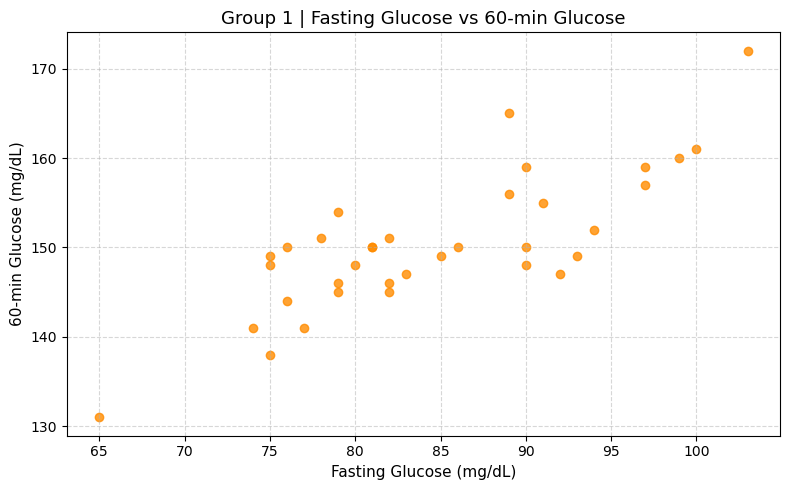

In [24]:
x = df1.Group1_Basal
y = df1.Group1_60min

cov  = x.cov(y)
corr = x.corr(y)
_, p_corr = stats.pearsonr(x, y)

print(f"Covariance: {cov:.4f}")
print(f"Pearson correlation: {corr:.4f}")
print(f"p-value: {p_corr:.2e}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="darkorange", alpha=0.8)
ax.set_title("Group 1 | Fasting Glucose vs 60-min Glucose", fontsize=13)
ax.set_xlabel("Fasting Glucose (mg/dL)", fontsize=11)
ax.set_ylabel("60-min Glucose (mg/dL)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

r = 0.796 indicates a strong positive linear relationship. The positive covariance and p < 0.01 confirm the association is statistically significant.

In [25]:
slope, intercept = np.polyfit(x, y, 1)
print(f"Model: Glucose_60min = {intercept:.4f} + {slope:.4f} × Glucose_basal")

# Prediction for a patient with fasting glucose  
x_new = float(input("Enter fasting glucose (mg/dL): "))
y_pred = intercept + slope * x_new
print(f"\nPredicted 60-min glucose for basal = {x_new} mg/dL: {y_pred:.2f} mg/dL")

Model: Glucose_60min = 91.3837 + 0.6969 × Glucose_basal


Enter fasting glucose (mg/dL):  80



Predicted 60-min glucose for basal = 80.0 mg/dL: 147.13 mg/dL


In [26]:
r2 = corr ** 2
print(f"R² = {r2:.4f}")
print(f"The model explains {r2*100:.1f}% of the variance in 60-min glucose.")
print(f"Unexplained variance: {(1 - r2)*100:.1f}%")

R² = 0.6343
The model explains 63.4% of the variance in 60-min glucose.
Unexplained variance: 36.6%


In [27]:
# Marginal effect
delta = float(input("Enter increase in fasting glucose (mg/dL): "))
effect = delta * slope
print(f"A {delta} mg/dL increase in fasting glucose → {effect:.4f} mg/dL increase in 60-min glucose")

Enter increase in fasting glucose (mg/dL):  5


A 5.0 mg/dL increase in fasting glucose → 3.4844 mg/dL increase in 60-min glucose


## 5. Inferential Statistics

### a) 95% and 99% confidence intervals and hypothesis testing for 88 mg/dL as the mean basal glucose level in first group 
H0: µ = 88

H1: µ ≠ 88 

In [28]:
# Verify normality first
_, p_norm = shapiro(df1.Group1_Basal)
print(f"Shapiro-Wilk p = {p_norm:.4f} → normality {'not rejected' if p_norm > 0.05 else 'rejected'}")

Shapiro-Wilk p = 0.3874 → normality not rejected


In [29]:
# Confidence intervals (t-distribution: small sample, unknown variance, normality not rejected)
desc = sm.stats.DescrStatsW(df1.Group1_Basal)
ic_95 = desc.tconfint_mean(alpha=0.05)
ic_99 = desc.tconfint_mean(alpha=0.01)

print(f"95% CI: [{ic_95[0]:.2f}, {ic_95[1]:.2f}]")
print(f"99% CI: [{ic_99[0]:.2f}, {ic_99[1]:.2f}]")

95% CI: [81.65, 87.72]
99% CI: [80.61, 88.76]


In [30]:
# Hypothesis test: H0: mu = 88
t_stat, p_val = stats.ttest_1samp(df1.Group1_Basal, popmean=88)
print(f"p-value: {p_val:.4f}")
print(f"At α=0.05 → H0 {'rejected' if p_val < 0.05 else 'not rejected'}")
print(f"At α=0.01 → H0 {'rejected' if p_val < 0.01 else 'not rejected'}")

p-value: 0.0334
At α=0.05 → H0 rejected
At α=0.01 → H0 not rejected


88 mg/dL falls outside the 95% CI but inside the 99% CI. H₀ is rejected at the 5% level but not at 1%.

### b) 95% confidence interval for the difference in means of the basal level between both control groups
H0: µ Grupo1 = µ Grupo2 

H1: µ Grupo1 ≠ µ Grupo2

In [31]:
# Verify normality for Group 2
_, p_norm = shapiro(df1.Group2_Basal.dropna())
print(f"Shapiro-Wilk p = {p_norm:.4f} → normality {'not rejected' if p_norm > 0.05 else 'rejected'}")

Shapiro-Wilk p = 0.4741 → normality not rejected


In [32]:
# Equal variances — Levene's test
lev_stat, lev_p = stats.levene(df1.Group1_Basal, df1.Group2_Basal.dropna())
print("Levene stat:", lev_stat)
print("p-value:", lev_p)

Levene stat: 1.4247828107303953
p-value: 0.23709323592519643


In [33]:
# 95% CI for difference of means (pooled variance)
cm = sms.CompareMeans(sms.DescrStatsW(df1.Group1_Basal),sms.DescrStatsW(df1.Group2_Basal.dropna()))
ic_dm = cm.tconfint_diff(alpha=0.05, usevar="pooled")
print(f"95% CI: [{ic_dm[0]:.2f}, {ic_dm[1]:.2f}]")

95% CI: [-8.79, -0.64]


### c) 98% confidence interval for the population proportion and test with a 5% significance level
H0: p = 0,15 

H1: p ≠ 0,15 

In [34]:
successes = (df["Nivel glucosa basal"] > 95).sum()
n_total = len(df["Nivel glucosa basal"])

p_sample = successes / n_total
p0 = 0.15

# 98% CI for proportion
ic_p = sm.stats.proportion_confint(successes, n_total, alpha=0.02)
print(f"98% CI: [{ic_p[0]:.3f}, {ic_p[1]:.3f}]")

98% CI: [0.061, 0.277]


In [35]:
# Z-test: H0: p = 0.15
z_stat = (p_sample - p0) / np.sqrt(p0 * (1 - p0) / n_total)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
z_critical = stats.norm.ppf(1 - 0.05 / 2)

print(f"Z-statistic: {z_stat:.4f}")
print(f"Critical value: {z_critical:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"H0 {'rejected' if abs(z_stat) > z_critical else 'not rejected'} at α=0.05")

Z-statistic: 0.4342
Critical value: 1.9600
p-value: 0.6641
H0 not rejected at α=0.05


### d) Detect if there is a significant change in blood glucose levels in the adult group after intake
H0: µ Basal = µ 60min  // H0: d = 0 

H1: µ Basal ≠ µ 60min // H1: d ≠ 0 

In [36]:
t_stat, p_val = stats.ttest_rel(df1.Group2_Basal.dropna(), df1.Group2_60min.dropna())
mean_diff = (df1.Group2_Basal.dropna() - df1.Group2_60min.dropna()).mean()

print(f"Mean difference (basal − 60min): {mean_diff:.4f} mg/dL")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.2e}")
print(f"H0 {'rejected' if p_val < 0.05 else 'not rejected'} at α=0.05")

Mean difference (basal − 60min): -82.4333 mg/dL
t-statistic: -34.3741
p-value: 4.71e-25
H0 rejected at α=0.05


The mean difference is −82.43 mg/dL and p ≈ 0 so H₀ is rejected. Blood glucose increases significantly 60 minutes after glucose intake in Group 2